# **Predictive Modeling: Dixon-Coles model**
**Project:**  FIFA World Cup 2026 — Prediction & Simulation Engine
**Module:** Statistical Inference & Probabilistic Outcomes  
**Objective:** To implement and calibrate a customized Dixon-Coles model. This notebook focuses on optimizing the $K$-factor and Draw Margin ($c$) through Ranked Probability Score (RPS) minimization, using a chronological burn-in strategy.

* **Unit 1: Theoretical Framework**
    * 1.1 The Bivariate Poisson Model
    * 1.2 The Dixon-Coles Correction (τ)
    * 1.3 Log-Likelihood with Temporal Decay
    * 1.4 Identifiability Constraint & Regularization

* **Unit 2: Data Preprocessing**
    * 2.1 Import libraries
    * 2.2 Loading & Sorting data

* **Unit 3: Model Estimation**
    * 3.1 The Vectorized Negative Log-Likelihood
    * 3.2 Analytical Gradient (Backward Pass)
    * 3.3 Parameter Initialization & Bounds

* **Unit 4: Hyperparameter Tuning (ξ)**
    * 4.1 Walk-Forward Validation Protocol
    * 4.2 Batch Updating Strategy
    * 4.3 ξ Grid Search & Results

* **Unit 5: Model Validation — Qatar 2022**
    * 5.1 Out-of-Sample Backtesting
    * 5.2 Match-by-Match Results

* **Unit 6: Predictive Engine for 2026**
    * 6.1 Final Parameter Consolidation
    * 6.2 Score Matrix & Probability Extraction
    * 6.3 Exporting Parameters for Tournament Simulation

## **Unit 1: Theoretical Framework**

### 1.1 The Bivariate Poisson Model

In this model we consider that the distribution of goals for each team follows a Poisson distribution, and the match score is obtaind by the product of the distribution for both teams:
$$P(X_i = x, Y_j = y) = \tau_{\rho}(x, y) \frac{\lambda_i^x e^{-\lambda_i}}{x!} \frac{\mu_j^y e^{-\mu_j}}{y!}$$
where$ X_i, Y_j$ are the teams; $x,y$ the goals of each team; $\lambda_i,\mu_j$ the expeted goal rate of each team; the function $\tau_{\rho}(x, y)$ is used to control the relevance of low score matches.
Furthermore, $\lambda = \exp(\alpha_i + \beta_j + \gamma)$ and $\mu = \exp(\alpha_j + \beta_i)$, where $\alpha_i,\beta_i$ are related with the offensive and defensive power of a team, respectively, and $\gamma$ is a home factor.

### 1.2 The Dixon-Coles Correction (τ)
    

The bivariate Poisson model underestimates the probabilities for low scores, in the Dixon coles the correcting function $\tau_{\rho}(x, y)$ is defined by
$$\tau_{\rho}(x,y) = \begin{cases} 1 - \lambda_i \mu_j \rho & \text{if } (x,y) = (0,0) \\ 1 + \lambda_i \rho & \text{if } (x,y) = (0,1) \\ 1 + \mu_j \rho & \text{if } (x,y) = (1,0) \\ 1 - \rho & \text{if } (x,y) = (1,1) \\ 1 & \text{in other case} \end{cases}$$
is introduced to fix this problem.
With this function, the model is
$$P(X_i = x, Y_j = y) = \tau_{\rho}(x, y) \frac{\lambda_i^x e^{-\lambda_i}}{x!} \frac{\mu_j^y e^{-\mu_j}}{y!}$$


### 1.3 Log-Likelihood with Temporal Decay

For parameter fitting Log-Likelihood function is introduced. Furthermor, the model includes a temporal decay factor to give more relevace to more recent results. The Log-likelihood function is
$$LL(\alpha, \beta, \gamma, \rho) = \sum_{k=1}^N e^{-\xi(T - t_k)} \log \left( \tau_{\rho}(x_k, y_k) \frac{\lambda_k^{x_k} e^{-\lambda_k}}{x_k!} \frac{\mu_k^{y_k} e^{-\mu_k}}{y_k!} \right)$$
where $T$ is the current time and $t_k$ is the date of match $k$. 

Is not possible to determinate the parameter $\xi$ simultaneously with the others parameters buecause, this will lead to choose $\xi$ to infinite for an ideal fitting of last matches and discart the previous. For this reason $\xi$ is treated as a fix hyperparameter for fitting  $\alpha, \beta, \gamma, y \rho$. The value of $\xi$ is determinated by grid search choosing the optimal for Ranked Probability Score (RPS).













For obtaining the values, we use historical data and a log likelihood function. Also, a parameter $\xi$ is included to soften the impact of older matches.
$$LL(\alpha, \beta, \gamma, \rho) = \sum_{k=1}^N e^{-\xi(T - t_k)} \log \left( \tau_{\rho}(x_k, y_k) \frac{\lambda_k^{x_k} e^{-\lambda_k}}{x_k!} \frac{\mu_k^{y_k} e^{-\mu_k}}{y_k!} \right)$$
where $T$ is the current time, $t_k$ is the time for the match $k$. For fitting the model, this function should be minimized.

Due that in a world cup, the home effect is neglectable, we will fix $\gamma=0$

## Output simulation

In order to simulate the results of a match, is necessary to fix a max number of expected goals, max_goals. We will discad the probability of more than max_goals goals per team. 
Given the parameters of the teams, a max_goals$\times$max_goals matrix is computed with the probabilities of each result; later, we normalize the values to fix the high score discarded results. The sum of probabilities under the diagonal gives us the home win probability; the sum of the diagonal values, the draw probability; and the sum of the rest, the away win probability.


## Evaluating the prediction

For prediction evaluation we use the Ranked Probability Score (RPS)
$$RPS = \frac{1}{r-1} \sum_{i=1}^{r-1} (P_i - O_i)^2$$
where:
- $P_i$: is the cumulative sum of predicted probabilities till category $i$.
- $O_i$: is the cumulative sum of the actual results till category $i$.
- $r$ is the total of possible results, in our case 3 (home win, draw, away win).
This metric is calculated for each predicted match.

## Validate the model

In order to validate the model we use a  Walk-Forward validation. We consider the matches till december 2002 to train the model, the window from jan 2003 to dec 2018 to validate the model and fit the $\xi$ parameter, from 2019 to now for testing. We do not use the standard of splitting the interval in three equal parts because we have a too long time interval and very old results are no relevant.

One of the drawbacks of this model is the cost of training, because a nonlinear optimization problem must be solved. In the standard way, the model should be fitted match by match. To accelerate this proccess we use a batch updating schema, fitting the parameters each 100 matches.



## **Unit 2: Data Preprocessing**
###  2.1 Import libraries

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import poisson
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from datetime import datetime
from collections import Counter

###   2.2 Loading & Sorting data

In [2]:
df= pd.read_parquet('../data/processed/results.parquet')
df = df.sort_values('date').reset_index(drop=True)

## Unit 3: Model Estimation
### 3.1 The Vectorized Negative Log-Likelihood and Analytical Gradient 

To obtain a better performance we vectorize some parameters and we define a Log-likelihood  function with analytical gradient 



In [3]:
def dc_neg_log_like_with_grad(params, h_idx, a_idx, x, y, is_home, t_diff, n_teams, xi=0.001, l2_reg=0.001):
    # unpacking parameters
    alphas = params[:n_teams]
    betas = params[n_teams:2*n_teams]
    gamma = params[2*n_teams]
    rho = params[2*n_teams + 1]
    
    # time weight
    weights = np.exp(-xi * t_diff)
    
    # offensive and deffensive intensities (λ and μ)
    lambda_x = np.exp(alphas[h_idx] + betas[a_idx] + gamma * is_home)
    mu_y = np.exp(alphas[a_idx] + betas[h_idx])
    
    # correction for low scores (tau)
    tau = np.ones_like(lambda_x)
    m00 = (x == 0) & (y == 0)
    m10 = (x == 1) & (y == 0)
    m01 = (x == 0) & (y == 1)
    m11 = (x == 1) & (y == 1)
    
    tau[m00] = 1.0 - lambda_x[m00] * mu_y[m00] * rho
    tau[m10] = 1.0 + lambda_x[m10] * rho
    tau[m01] = 1.0 + mu_y[m01] * rho
    tau[m11] = 1.0 - rho
    
    # ovoiding nummerical issues
    eps = 1e-10
    lambda_x = np.clip(lambda_x, eps, 1e10)
    mu_y = np.clip(mu_y, eps, 1e10)
    tau = np.clip(tau, eps, None)
    
    # objective function Negative Log-Likelihood (NLL)
    # Poisson: lambda - x*log(lambda) | Dixon-Coles: -log(tau)
    poisson_part = lambda_x + mu_y - x * np.log(lambda_x) - y * np.log(mu_y)
    nll = np.sum(weights * (poisson_part - np.log(tau)))
    
    # L2 regularization
    nll += l2_reg * (np.sum(alphas**2) + np.sum(betas**2))
    
    # gradient function
    A = np.zeros_like(lambda_x)
    B = np.zeros_like(lambda_x)
    
    A[m00], B[m00] = -mu_y[m00] * rho / tau[m00], -lambda_x[m00] * rho / tau[m00]
    A[m10] = rho / tau[m10]
    B[m01] = rho / tau[m01]
    
    # partial derivatives
    d_lambda = weights * (lambda_x - x - A * lambda_x)
    d_mu = weights * (mu_y - y - B * mu_y)
    
    # group by teams (Alphas y Betas)
    grad_alphas = np.bincount(h_idx, weights=d_lambda, minlength=n_teams) + \
                  np.bincount(a_idx, weights=d_mu, minlength=n_teams)
                  
    grad_betas = np.bincount(a_idx, weights=d_lambda, minlength=n_teams) + \
                 np.bincount(h_idx, weights=d_mu, minlength=n_teams)
    
    # gamma and rho derivative
    grad_gamma = np.sum(d_lambda * is_home)
    
    grad_rho_part = np.zeros_like(lambda_x)
    grad_rho_part[m00] = -lambda_x[m00] * mu_y[m00] / tau[m00]
    grad_rho_part[m10] = lambda_x[m10] / tau[m10]
    grad_rho_part[m01] = mu_y[m01] / tau[m01]
    grad_rho_part[m11] = -1.0 / tau[m11]
    grad_rho = -np.sum(weights * grad_rho_part)
    
    # L2 regularization 
    grad_alphas += 2 * l2_reg * alphas
    grad_betas += 2 * l2_reg * betas
    
    
    grad = np.concatenate([grad_alphas, grad_betas, [grad_gamma, grad_rho]])
    
    return nll, grad

### 3.3 Parameter Initialization & Bounds

We set an initial parameter guess with: $\alpha_i=\beta_i=0$ for all teams; $\gamma=0.25$ for the home advantage factor and $\rho=1$, the $\tau$ function parameter.  
For the log-likelihood function the parameters are unbounded with exception of $\left|\rho\right|\leq 1$

In [4]:
df = df.sort_values('date').reset_index(drop=True)
unique_teams = sorted(list(set(df['home_team']).union(set(df['away_team']))))
team_to_id = {team: i for i, team in enumerate(unique_teams)}
n_teams = len(unique_teams)

params_guess = np.zeros(2 * n_teams + 2)
params_guess[2*n_teams] = 0.25 
params_guess[2*n_teams + 1] = 0.0 
    
bounds = ([(None, None)] * (2 * n_teams + 1)) + [(-0.15, 0.15)]

## **Unit 4: Hyperparameter Tuning (ξ)**
### 4.1 Walk-Forward Validation Protocol

Walk-forward validation is a time-series evaluation method in which a model is trained on past observations and tested on future observations. The training window is then moved forward (or expanded), the model is re-estimated, and the process is repeated sequentially through the training set.


### 4.2 Batch Updating Strategy

Due that, for every re-estimation we need to solve a optimization problem, we introduce a batch strategy:
* We consider an intial training set for calculate a initial estimation of paramters.
* Whit this parameters we predict next $k$ matches and compute the RPS.
* After $k$ matches we update the paramters.
This procedure is done till the end of training set.

The optimization problem is solved using a warm-started L-BFFGS, using the previos batch parameters as initial guess for the new optimization problem.

In [5]:

def calculate_rps(probs, actual_outcome):
    """Ranked Probability Score para 3 categorías (Local, Empate, Visitante)"""
    p_cum = np.cumsum(probs)
    e = np.zeros(3)
    e[actual_outcome] = 1.0
    e_cum = np.cumsum(e)
    return np.sum((p_cum[:2] - e_cum[:2])**2) / 2.0

def predict_match_fast(h_idx, a_idx, params, n_teams, max_goals=8):
    alphas = params[0:n_teams]
    betas = params[n_teams:2*n_teams]
    gamma = params[2*n_teams]
    rho = params[2*n_teams + 1]
    
    lx = np.exp(alphas[h_idx] + betas[a_idx] + gamma)
    my = np.exp(alphas[a_idx] + betas[h_idx])
    
    # score probability matrix
    goals = np.arange(max_goals + 1)
    px = poisson.pmf(goals, lx)
    py = poisson.pmf(goals, my)
    prob_matrix = np.outer(px, py)
    
    # rho correction
    prob_matrix[0,0] *= (1 - lx*my*rho)
    prob_matrix[0,1] *= (1 + lx*rho)
    prob_matrix[1,0] *= (1 + my*rho)
    prob_matrix[1,1] *= (1 - rho)
    
    prob_matrix /= prob_matrix.sum()

    h_score, a_score = np.unravel_index(np.argmax(prob_matrix), prob_matrix.shape)
    return [
        np.sum(np.tril(prob_matrix, -1)), # Home
        np.sum(np.diag(prob_matrix)),     # Draw
        np.sum(np.triu(prob_matrix, 1)),  # Away
        h_score, a_score,np.argmax(prob_matrix)
    ]

def run_fast_walk_forward(df, initial_train_size=45, xi=0.005, batch_size=1, matches_bound=len(df),large_visualization=False):
    print(xi)
    
    unique_teams = sorted(list(set(df['home_team']).union(set(df['away_team']))))
    team_to_id = {team: i for i, team in enumerate(unique_teams)}
    n_teams = len(unique_teams)
    
    h_idx_all = df['home_team'].map(team_to_id).values
    a_idx_all = df['away_team'].map(team_to_id).values
    h_goals_all = df['home_score'].values
    a_goals_all = df['away_score'].values
    dates_all = df['date'].values
    
    rps_scores = []
    params_guess = np.zeros(2 * n_teams + 2)
    params_guess[2*n_teams] = 0.25 
    params_guess[2*n_teams + 1] = 0.0 
    
    bounds = ([(None, None)] * (2 * n_teams + 1)) + [(-0.15, 0.15)]

    print(f"Validation over {matches_bound - initial_train_size} matches...")

    for i in range(initial_train_size, matches_bound):
        # 1. Calculate/Update the parameters
        if (i - initial_train_size) % batch_size == 0:
            h_idx_train = h_idx_all[:i]
            a_idx_train = a_idx_all[:i]
            x_train = h_goals_all[:i]
            y_train = a_goals_all[:i]
            is_home_train = np.ones(len(x_train)) 
            
            # time factor
            last_date = pd.to_datetime(dates_all[i-1])
            past_dates = pd.to_datetime(dates_all[:i])
            # t_diff in weeks
            t_diff = (last_date - past_dates).days / 7.0
            
            
            res = minimize(
                fun=dc_neg_log_like_with_grad,
                x0=params_guess,
                args=(h_idx_train, a_idx_train, x_train, y_train, is_home_train, t_diff, n_teams, xi, 0.001),
                jac=True,
                method='L-BFGS-B',
                bounds=bounds
            )
            if res.success:
                params_guess = res.x
        
        # 2. Predict the current match
        probs_data = predict_match_fast(h_idx_all[i], a_idx_all[i], params_guess, n_teams)
        
        # 3. Extract probabilities
        p_home, p_draw, p_away, lx, my ,*_= probs_data
        probs = [p_home, p_draw, p_away]
        
        # 4. Calculate rps
        actual = 0 if h_goals_all[i] > a_goals_all[i] else (1 if h_goals_all[i] == a_goals_all[i] else 2)
        current_rps = calculate_rps(probs, actual)
        rps_scores.append(current_rps)

        # 5. Large visualization
        if large_visualization:
            date_str = pd.to_datetime(dates_all[i]).strftime('%Y-%m-%d')
            h_team, a_team = unique_teams[h_idx_all[i]], unique_teams[a_idx_all[i]]
            score_str = f"{h_goals_all[i]} - {a_goals_all[i]}"
            outcomes = ["L", "E", "V"]
            pred_outcome = outcomes[np.argmax(probs)]
            real_outcome = outcomes[actual]
            match_status = "✅" if pred_outcome == real_outcome else "❌"
            print(f"[{date_str}] {h_team:<20} {score_str:^7} {a_team:>20} | {match_status}")
            print(f"  └─ Pred: L: {p_home:>6.1%} | E: {p_draw:>6.1%} | V: {p_away:>6.1%}")
            print(f"  └─ Intensities (λ, μ): ({lx:.2f}, {my:.2f}) | RPS: {current_rps:.4f}")
            print("-" * 85)
        
        if i % 100 == 0:
            print(f"Processed: {i}/{matches_bound} | Cumulative RPS: {np.mean(rps_scores):.4f}")

    print(f"\nFinished. Average RPS: {np.mean(rps_scores):.4f}")
    return np.mean(rps_scores),params_guess




### 4.3 ξ Grid Search & Results

The selection of the optimal $\xi$ is done throug a grid search in the interval $\left[0.001, 0.008\right]$ using the walk-foward prodecure. The matches previous to year 2008 was considered for the initial test and the test set includes matches previous to 2022 world cup. The update of parameters was each 50 matches.


Beginning hyper-parameter setup...
Initial training: 13433 | final match in train set: 21728
0.001
Validation over 8295 matches...
Processed: 13500/21728 | Cumulative RPS: 0.1959
Processed: 13600/21728 | Cumulative RPS: 0.1661
Processed: 13700/21728 | Cumulative RPS: 0.1825
Processed: 13800/21728 | Cumulative RPS: 0.1748
Processed: 13900/21728 | Cumulative RPS: 0.1723
Processed: 14000/21728 | Cumulative RPS: 0.1642
Processed: 14100/21728 | Cumulative RPS: 0.1681
Processed: 14200/21728 | Cumulative RPS: 0.1724
Processed: 14300/21728 | Cumulative RPS: 0.1686
Processed: 14400/21728 | Cumulative RPS: 0.1667
Processed: 14500/21728 | Cumulative RPS: 0.1676
Processed: 14600/21728 | Cumulative RPS: 0.1697
Processed: 14700/21728 | Cumulative RPS: 0.1710
Processed: 14800/21728 | Cumulative RPS: 0.1726
Processed: 14900/21728 | Cumulative RPS: 0.1726
Processed: 15000/21728 | Cumulative RPS: 0.1739
Processed: 15100/21728 | Cumulative RPS: 0.1727
Processed: 15200/21728 | Cumulative RPS: 0.1713
Proce

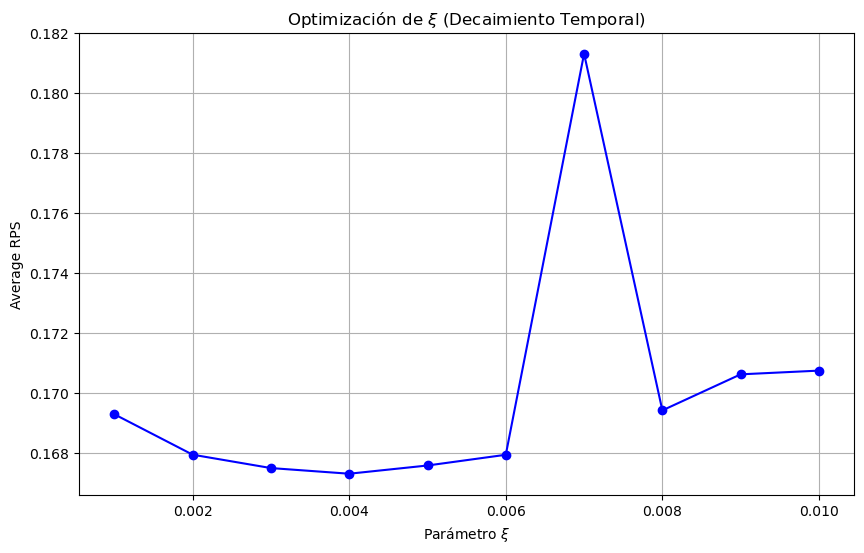

In [6]:
xi_values = np.linspace(0.001, 0.01, 10)

results_xi = []

print(f"Beginning hyper-parameter setup...")
print(f"Initial training: 13433 | final match in train set: 21728")

for value in xi_values:
    avg_rps = run_fast_walk_forward(
        df, 
        initial_train_size=13433, 
        matches_bound=21728, 
        xi=value, 
        batch_size=50, 
        large_visualization=False
    )
    results_xi.append(avg_rps[0])

# Output visualization
plt.figure(figsize=(10, 6))
plt.plot(xi_values, results_xi, marker='o', linestyle='-', color='b')
plt.title('Optimización de $\\xi$ (Decaimiento Temporal)')
plt.xlabel('Parámetro $\\xi$')
plt.ylabel('Average RPS')
plt.grid(True)
plt.show()


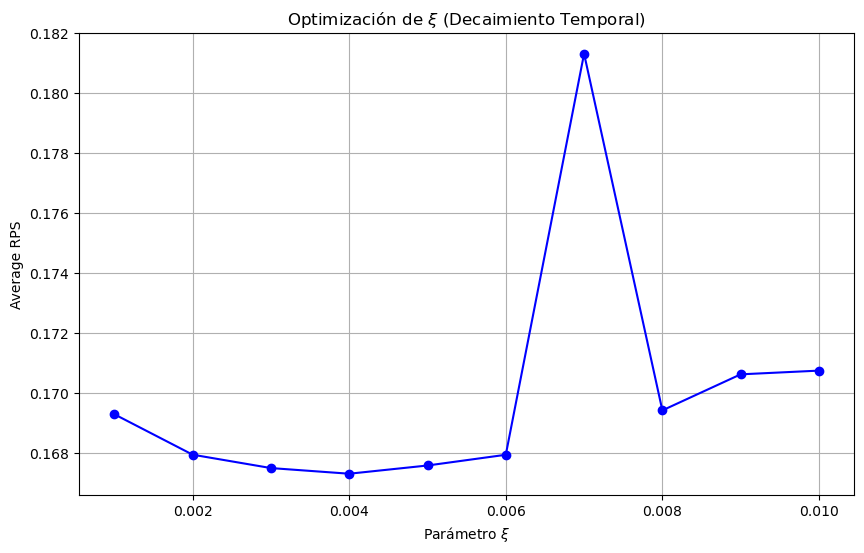

The best xi value is: 0.004 with 0.1673 RPS 


In [7]:
# Output visualization
plt.figure(figsize=(10, 6))
plt.plot(xi_values, results_xi, marker='o', linestyle='-', color='b')
plt.title('Optimización de $\\xi$ (Decaimiento Temporal)')
plt.xlabel('Parámetro $\\xi$')
plt.ylabel('Average RPS')
plt.grid(True)
plt.show()

# the best
best_xi = xi_values[np.argmin(results_xi)]
print(f"The best xi value is: {best_xi} with {min(results_xi):.4f} RPS ")

## **Unit 5: Model Validation — Qatar 2022**
### 5.1 Out-of-Sample Backtesting
For testing the performance of our model with the optimal parameters obtained We execute a validation phase using the FIFA World Cup 2022 matches. This dataset was not included in the parameter calibration phase, serving as an "out-of-sample" test.

During this phase: Neutral Ground Assumption: We set the Home Field Advantage () to 0, as World Cup matches are played in neutral venues (with the exception of the host nation, which we generalize for model simplicity). Iterative Evaluation: Ratings continue to update after each match, but we start recording the RPS to measure how well the model's probabilities align with the tournament's surprises and certainties.

### 5.2 Match-by-Match Results

To validate the model we made a prediction for each match of WC2022. During the WC2022 we consider that the parameters remain constant. This is not absolutely true, but the teams themselves only change by injuries or red cards, except for a very particular combination of team and player, which are minor changes. Aslo we consider that there is no local advantage.

In [8]:
def WC_past_sim(df,params, initial=45, xi=0.005, batch_size=1, matches_bound=len(df),large_visualization=False):
    sim_results = []
    rps_scores = []
    
    unique_teams = sorted(list(set(df['home_team']).union(set(df['away_team']))))
    team_to_id = {team: i for i, team in enumerate(unique_teams)}
    n_teams = len(unique_teams)
    h_idx_all = df['home_team'].map(team_to_id).values
    a_idx_all = df['away_team'].map(team_to_id).values
    h_goals_all = df['home_score'].values
    a_goals_all = df['away_score'].values
    dates_all = df['date'].values
    
    params_guess = params

    # We fix the 0 bounds for gamma
    bounds = ([(None, None)] * (2 * n_teams +1 ))  + [(-0.15, 0.15)]
    h_idx_train = h_idx_all[:initial]
    a_idx_train = a_idx_all[:initial]
    x_train = h_goals_all[:initial]
    y_train = a_goals_all[:initial]
    is_home_train = np.ones(len(x_train)) 
            
    # calculate decay
    last_date = pd.to_datetime(dates_all[initial-1])
    past_dates = pd.to_datetime(dates_all[:initial])
    # t_diff in weeks
    t_diff = (last_date - past_dates).days / 7.0

    res = minimize(
                fun=dc_neg_log_like_with_grad,
                x0=params_guess,
                args=(h_idx_train, a_idx_train, x_train, y_train, is_home_train, t_diff, n_teams, xi, 0.001),
                jac=True,
                method='L-BFGS-B',
                bounds=bounds
            )
    
    if res.success:
        params = res.x
        params[2*n_teams ] = 0.0 

    for i in range(initial, matches_bound):
        # 2. Predict the current match
        probs_data = predict_match_fast(h_idx_all[i], a_idx_all[i], params, n_teams)
        
        # Extract probabilities
        p_home, p_draw, p_away, h_score, a_score,prob = probs_data
        probs = [p_home, p_draw, p_away]

        # expected goals
        h_idx = h_idx_all[i]
        a_idx = a_idx_all[i]
        lx = np.exp(params[h_idx] + params[a_idx+n_teams])
        my = np.exp(params[a_idx] + params[h_idx+n_teams])
        lambda_h = lx
        lambda_a = my
        
        # Calculate rps
        actual = 0 if h_goals_all[i] > a_goals_all[i] else (1 if h_goals_all[i] == a_goals_all[i] else 2)
        current_rps = calculate_rps(probs, actual)
        rps_scores.append(current_rps)

        # Large visualization
        h_team, a_team = unique_teams[h_idx_all[i]], unique_teams[a_idx_all[i]]
        if large_visualization:
            date_str = pd.to_datetime(dates_all[i]).strftime('%Y-%m-%d')
            score_str = f"{h_goals_all[i]} - {a_goals_all[i]}"
            outcomes = ["L", "E", "V"]
            pred_outcome = outcomes[np.argmax(probs)]
            real_outcome = outcomes[actual]
            match_status = "✅" if pred_outcome == real_outcome else "❌"
            print(f"[{date_str}] {h_team:<20} {score_str:^7} {a_team:>20} | {match_status}")
            print(f"  └─ Pred: L: {p_home:>6.1%} | E: {p_draw:>6.1%} | V: {p_away:>6.1%}")
            print(f"  └─ Intensities (λ, μ): ({lx:.2f}, {my:.2f}) | RPS: {current_rps:.4f}")
            print("-" * 85)
        
        if i % 100 == 0:
            print(f"Processed: {i}/{matches_bound} | Cumulative RPS: {np.mean(rps_scores):.4f}")
            
        sim_results.append({
            'Match': f"{h_team} vs {a_team}",
            'Actual': f"{int(h_goals_all[i])}-{int(a_goals_all[i])}",
            'Predicted Score (Mode)': f"{int(h_score)}-{int(a_score)}",
            'Score Confidence': f"{prob:.1%}",
            'Exp Goals': f'{lx:.2f}-{my:.2f}',
            'P_Home': f"{p_home:.1%}",
            'P_Draw': f"{p_draw:.1%}",
            'P_Away': f"{p_away:.1%}"
        })
    print(f"\nFinished. Average RPS: {np.mean(rps_scores):.4f}")
    return np.mean(rps_scores),pd.DataFrame(sim_results)

WC_2022_BEG=21716
WC_2022_END = 21780
i=21715
xi=0.004

unique_teams = sorted(list(set(df['home_team']).union(set(df['away_team']))))
team_to_id = {team: i for i, team in enumerate(unique_teams)}
n_teams = len(unique_teams)
    
h_idx_all = df['home_team'].map(team_to_id).values
a_idx_all = df['away_team'].map(team_to_id).values
h_goals_all = df['home_score'].values
a_goals_all = df['away_score'].values
dates_all = df['date'].values

params_guess = np.zeros(2 * n_teams + 2)
params_guess[2*n_teams] = 0.0
params_guess[2*n_teams + 1] =  0.25
    
bounds = ([(None, None)] * (2 * n_teams + 1)) + [(-0.15, 0.15)]

h_idx_train = h_idx_all[:i]
a_idx_train = a_idx_all[:i]
x_train = h_goals_all[:i]
y_train = a_goals_all[:i]
is_home_train = np.ones(len(x_train)) 
            
# time factor
last_date = pd.to_datetime(dates_all[i-1])
past_dates = pd.to_datetime(dates_all[:i])
# t_diff in weeks
t_diff = (last_date - past_dates).days / 7.0

res = minimize(
                fun=dc_neg_log_like_with_grad,
                x0=params_guess,
                args=(h_idx_train, a_idx_train, x_train, y_train, is_home_train, t_diff, n_teams, xi, 0.001),
                jac=True,
                method='L-BFGS-B',
                bounds=bounds
            )


params = res.x

WC_past_sim(df,params, initial=WC_2022_BEG, xi=0.004, batch_size=100, matches_bound=WC_2022_END,large_visualization=True)    

[2022-11-20] Qatar                0.0 - 2.0              Ecuador | ✅
  └─ Pred: L:  14.4% | E:  19.1% | V:  66.5%
  └─ Intensities (λ, μ): (0.65, 1.80) | RPS: 0.0666
-------------------------------------------------------------------------------------
[2022-11-21] Senegal              0.0 - 2.0          Netherlands | ✅
  └─ Pred: L:  15.0% | E:  20.8% | V:  64.2%
  └─ Intensities (λ, μ): (0.61, 1.64) | RPS: 0.0752
-------------------------------------------------------------------------------------
[2022-11-21] England              6.0 - 2.0                 Iran | ✅
  └─ Pred: L:  53.0% | E:  28.4% | V:  18.7%
  └─ Intensities (λ, μ): (1.15, 0.53) | RPS: 0.1281
-------------------------------------------------------------------------------------
[2022-11-21] United States        1.0 - 1.0                Wales | ❌
  └─ Pred: L:  31.5% | E:  28.7% | V:  39.9%
  └─ Intensities (λ, μ): (0.83, 0.98) | RPS: 0.1290
------------------------------------------------------------------------------

(np.float64(0.21386200996237104),
                         Match Actual Predicted Score (Mode) Score Confidence  \
 0            Qatar vs Ecuador    0-2                    0-1           100.0%   
 1      Senegal vs Netherlands    0-2                    0-1           100.0%   
 2             England vs Iran    6-2                    1-0           900.0%   
 3      United States vs Wales    1-1                    0-1           100.0%   
 4   Argentina vs Saudi Arabia    1-2                    1-0           900.0%   
 ..                        ...    ...                    ...              ...   
 59          England vs France    1-2                    1-0           900.0%   
 60       Argentina vs Croatia    3-0                    1-0           900.0%   
 61          France vs Morocco    2-0                    1-0           900.0%   
 62         Croatia vs Morocco    2-1                    1-0           900.0%   
 63        Argentina vs France    3-3                    1-0           900.

## Unit 5: Predictive Engine for 2026
### 5.1 Final Rating Consolidation

Before moving to the simulation phase, we consolidate the final parameters for all 48 teams participating in the 2026 World Cup. These values, adjusted after the 2022 cycle, represent our "Ground Truth" for the starting strength of each nation.

### 5.2 Dixon-Coles-Based Simulation

In this model the score of each team is not independent, therefore we need to calcule the probability matrix before to be able to make a simulation.
For each possible score outcome we compute the probability
$$P(X_i = x, Y_j = y) = \tau_{\rho}(x, y) \frac{\lambda_i^x e^{-\lambda_i}}{x!} \frac{\mu_j^y e^{-\mu_j}}{y!}$$
we present the results in a matrix where the $i,j$ position corresponds to $\left(i-1 \ ;\  j-1\right)$ score. Due to the fact that we limit the max goals, the matrix of probabilities do not sum 1. Therefore we normalize this matrix.

Using this matrix is possible to make a Montecarlo simulation for each match.

In [9]:
def simulate_match(h_idx, a_idx, params, n_teams, n_simulations=10000, max_goals=8):    
    alphas = params[0:n_teams]
    betas = params[n_teams:2*n_teams]
    gamma = params[2*n_teams]
    rho = params[2*n_teams + 1]
    
    lx = np.exp(alphas[h_idx] + betas[a_idx] + gamma)
    my = np.exp(alphas[a_idx] + betas[h_idx])
    
    goals = np.arange(max_goals)
    px = poisson.pmf(goals, lx)
    py = poisson.pmf(goals, my)
    prob_matrix = np.outer(px, py)
    
    # Apply rho correction
    prob_matrix[0,0] *= (1 - lx*my*rho)
    prob_matrix[0,1] *= (1 + lx*rho)
    prob_matrix[1,0] *= (1 + my*rho)
    prob_matrix[1,1] *= (1 - rho)
    prob_matrix /= prob_matrix.sum()
    
    # Montecarlo: n_simulations
    plain_results = prob_matrix.flatten()
    indices = np.random.choice(
        range(len(plain_results)), 
        size=1, 
        p=plain_results
    )
    
    # convert index to scores
    score_h, score_a = np.divmod(indices, max_goals)
    
    return (score_h, score_a )

    


def simulate_match_montecarlo(h_idx, a_idx, params, n_teams, n_simulations=10000, max_goals=8):    
    alphas = params[0:n_teams]
    betas = params[n_teams:2*n_teams]
    gamma = params[2*n_teams]
    rho = params[2*n_teams + 1]
    
    lx = np.exp(alphas[h_idx] + betas[a_idx] + gamma)
    my = np.exp(alphas[a_idx] + betas[h_idx])
    
    goals = np.arange(max_goals)
    px = poisson.pmf(goals, lx)
    py = poisson.pmf(goals, my)
    prob_matrix = np.outer(px, py)
    
    # Apply rho correction
    prob_matrix[0,0] *= (1 - lx*my*rho)
    prob_matrix[0,1] *= (1 + lx*rho)
    prob_matrix[1,0] *= (1 + my*rho)
    prob_matrix[1,1] *= (1 - rho)
    prob_matrix /= prob_matrix.sum()
    
    # Montecarlo: n_simulations
    plain_results = prob_matrix.flatten()
    indices = np.random.choice(
        range(len(plain_results)), 
        size=n_simulations, 
        p=plain_results
    )
    
    # convert index to scores
    score_h, score_a = np.divmod(indices, max_goals)
    
    # combine scores
    pairs = list(zip(score_h, score_a))

    # frequency count
    conteo = Counter(pairs)
    
    # obtain the mode
    mode_score, frecuency = conteo.most_common(1)[0]
    print(mode_score)
    # calculate probability score
    probability_score = (frecuency / len(score_h))

    
    e_b = np.ones(max_goals) @ prob_matrix @ np.arange(max_goals)
    e_a = np.arange(max_goals) @prob_matrix @ np.ones(max_goals)
    return prob_matrix, (mode_score[0], mode_score[1]), probability_score, (e_a,e_b)




In [10]:
simulate_match_montecarlo(159, 59, params, n_teams, n_simulations=10000, max_goals=8)

(np.int64(0), np.int64(1))


(array([[5.35625928e-02, 1.41919162e-01, 1.13071970e-01, 6.78307223e-02,
         3.05182193e-02, 1.09845413e-02, 3.29475719e-03, 8.47067685e-04],
        [7.64959324e-02, 9.21431901e-02, 9.75454602e-02, 5.85165276e-02,
         2.63276015e-02, 9.47619590e-03, 2.84233668e-03, 7.30752347e-04],
        [2.59820664e-02, 4.67591306e-02, 4.20754889e-02, 2.52406571e-02,
         1.13562097e-02, 4.08748470e-03, 1.22602021e-03, 3.15204442e-04],
        [7.47144387e-03, 1.34461291e-02, 1.20992938e-02, 7.25824305e-03,
         3.26560953e-03, 1.17540353e-03, 3.52556300e-04, 9.06406850e-05],
        [1.61137511e-03, 2.89994253e-03, 2.60946896e-03, 1.56539384e-03,
         7.04297860e-04, 2.53500666e-04, 7.60362330e-05, 1.95485834e-05],
        [2.78021737e-04, 5.00347221e-04, 4.50229799e-04, 2.70088269e-04,
         1.21517400e-04, 4.37382301e-05, 1.31190593e-05, 3.37285284e-06],
        [3.99741840e-05, 7.19403170e-05, 6.47343946e-05, 3.88335037e-05,
         1.74718674e-05, 6.28871711e-06, 1.88